# 03 — 5-Fold Scene-Aware Cross-Validation Splits for v1.0-trainval Subset
## Multi-Attribute Scene Classification on nuScenes

**Purpose:** Create 5-fold scene-aware cross-validation splits for the 150-scene subset, matching the Stage 1 (v1.0-mini) protocol so the two stages are directly comparable.

### Why 5-fold CV (changed from single 70/15/15 split)

This notebook previously produced a single 70/15/15 split. It now uses 5-fold scene-aware CV for two reasons:

1. **Comparability with Stage 1.** Stage 1 (mini) uses 5-fold scene-aware CV. The central contribution of this study is the *cross-stage scaling comparison*, which is only valid if both stages share an identical evaluation protocol. A 5-fold mean cannot be fairly compared against a single-split point estimate.
2. **Honest variance estimates.** A single split yields one number from one partition; a favourable partition can produce misleadingly high scores (e.g. a perfect 1.000 on time_of_day). 5-fold CV averages across five test partitions and reports mean ± std.

### Protocol (identical to Stage 1)

| Aspect | Setting |
|---|---|
| Outer CV | 5-fold, scene-aware, stratified on `time_of_day` |
| Inner CV (tuning) | 3-fold StratifiedKFold on each outer training set (done in notebook 04) |
| Grouping unit | scene (no scene spans two folds) |
| Seed | 42 |

### Scene-aware guarantee

We assign whole **scenes** to folds, then propagate each scene's fold to its keyframes. Because the atomic unit is the scene, no scene's keyframes are split across folds — preventing the "easy memorization" leakage where train and test see different keyframes of the same drive.

### Inputs
- `data/processed/v1.0-trainval/labels/attribute_labels.csv` (from 01)
- `data/processed/v1.0-trainval/selected_scenes.csv` (from 00b)

### Outputs
- `data/processed/v1.0-trainval/splits/scene_fold_assignments.csv` — per-scene fold id
- `data/processed/v1.0-trainval/splits/sample_fold_assignments.csv` — per-keyframe fold id
- `data/processed/v1.0-trainval/splits/kfold_metadata.json` — fold stats, distributions, single-class-fold flags

> **Note:** This replaces the old single-split outputs (`scene_split_assignments.csv`, `sample_split_assignments.csv`, `split_metadata.json`), which are now obsolete and can be deleted.


## 0. Setup

In [4]:
import os
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 100

print('Imports OK')

Imports OK


## 0.1 Locate Project Root

In [5]:
def find_project_root():
    p = Path.cwd().resolve()
    for candidate in [p, *p.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    raise FileNotFoundError(f'Could not find project root from {p}')

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
print(f'Project root: {PROJECT_ROOT}')

Project root: C:\Users\leemi\Documents\GitHub\nuscenes-scene-classification-ml


## 1. Configuration

In [6]:
DATASET_VERSION = 'v1.0-trainval'

# Paths
PROCESSED_DIR = Path('data/processed') / DATASET_VERSION
LABELS_PATH   = PROCESSED_DIR / 'labels' / 'attribute_labels.csv'
SCENES_PATH   = PROCESSED_DIR / 'selected_scenes.csv'
SPLITS_DIR    = PROCESSED_DIR / 'splits'
FIG_DIR       = Path('results') / DATASET_VERSION / 'figures'

SPLITS_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

# CV design — matches Stage 1 (mini) notebook 04
N_FOLDS     = 5
SPLIT_SEED  = 42             # matches Stage 1 convention
STRATIFY_ON = 'time_of_day'  # scene-level stratification, same as Stage 1

print(f'DATASET_VERSION = {DATASET_VERSION}')
print(f'N_FOLDS         = {N_FOLDS}')
print(f'Seed            = {SPLIT_SEED}')
print(f'Stratification  = scene-level {STRATIFY_ON}')

DATASET_VERSION = v1.0-trainval
N_FOLDS         = 5
Seed            = 42
Stratification  = scene-level time_of_day


## 2. Load Inputs

In [7]:
# Load per-keyframe labels (from notebook 01)
df_labels = pd.read_csv(LABELS_PATH)
print(f'Loaded {len(df_labels)} keyframes from {LABELS_PATH}')

# Load per-scene metadata (from notebook 00b)
df_scenes = pd.read_csv(SCENES_PATH)
print(f'Loaded {len(df_scenes)} scenes from {SCENES_PATH}')

# Verify consistency
unique_scenes_in_labels = df_labels['scene_token'].nunique()
print(f'\nUnique scenes in labels CSV: {unique_scenes_in_labels}')
assert unique_scenes_in_labels == len(df_scenes), \
    f'Mismatch: {unique_scenes_in_labels} scenes in labels vs {len(df_scenes)} in selected'

Loaded 6021 keyframes from data\processed\v1.0-trainval\labels\attribute_labels.csv
Loaded 150 scenes from data\processed\v1.0-trainval\selected_scenes.csv

Unique scenes in labels CSV: 150


## 3. Assign Scenes to Folds (Scene-Aware, Stratified)

We assign each of the 150 scenes to one of the 5 folds using `StratifiedKFold` on the **scene table**, stratified by `time_of_day`. Each scene's `fold` value is the fold in which that scene serves as the **test** set; for fold *k*, training uses all scenes with `fold != k`.

Because we assign whole scenes (not keyframes), scene-awareness is guaranteed by construction.

In [8]:
# Assign each scene to a fold (the fold in which it is the TEST set)
df_scenes = df_scenes.reset_index(drop=True)
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SPLIT_SEED)

df_scenes['fold'] = -1
strat_values = df_scenes[STRATIFY_ON].values
for fold_idx, (_, test_idx) in enumerate(skf.split(df_scenes, strat_values)):
    df_scenes.loc[df_scenes.index[test_idx], 'fold'] = fold_idx

assert (df_scenes['fold'] >= 0).all(), 'Some scenes were not assigned to a fold'

print('Scene-level fold assignment (scenes per fold):')
print(df_scenes.groupby('fold').size().rename('n_scenes').to_string())
print()
print('time_of_day per fold (each fold shown as its TEST set):')
print(pd.crosstab(df_scenes['fold'], df_scenes[STRATIFY_ON]))

Scene-level fold assignment (scenes per fold):
fold
0    30
1    30
2    30
3    30
4    30

time_of_day per fold (each fold shown as its TEST set):
time_of_day  day  night
fold                   
0             24      6
1             24      6
2             24      6
3             24      6
4             24      6


## 4. Save Scene-to-Fold Mapping

In [9]:
df_scenes[['scene_token', 'scene_name', 'time_of_day', 'weather',
           'location', 'n_samples', 'fold']].to_csv(
    SPLITS_DIR / 'scene_fold_assignments.csv', index=False)
print(f'Saved → {SPLITS_DIR / "scene_fold_assignments.csv"}')
print()
print('Per-fold stratum distribution (time_of_day x weather):')
print(pd.crosstab(df_scenes['fold'],
                  [df_scenes['time_of_day'], df_scenes['weather']]))

Saved → data\processed\v1.0-trainval\splits\scene_fold_assignments.csv

Per-fold stratum distribution (time_of_day x weather):
time_of_day   day      night     
weather     clear rain clear rain
fold                             
0              18    6     6    0
1              22    2     4    2
2              20    4     6    0
3              19    5     6    0
4              16    8     3    3


## 5. Propagate Folds to Keyframe Level

In [10]:
scene_to_fold = dict(zip(df_scenes['scene_token'], df_scenes['fold']))
df_labels['fold'] = df_labels['scene_token'].map(scene_to_fold)

assert df_labels['fold'].notna().all(), 'Some keyframes have no fold assignment!'
df_labels['fold'] = df_labels['fold'].astype(int)

df_labels[['sample_token', 'scene_token', 'fold',
           'time_of_day', 'weather', 'vehicle_density', 'vru_present']].to_csv(
    SPLITS_DIR / 'sample_fold_assignments.csv', index=False)
print(f'Saved → {SPLITS_DIR / "sample_fold_assignments.csv"}  ({len(df_labels)} keyframes)')
print()
print('Keyframes per fold:')
print(df_labels.groupby('fold').size().rename('n_keyframes').to_string())

Saved → data\processed\v1.0-trainval\splits\sample_fold_assignments.csv  (6021 keyframes)

Keyframes per fold:
fold
0    1203
1    1199
2    1206
3    1209
4    1204


## 6. Verify NO Scene Leakage

The critical check: ensure no scene appears in more than one fold, and that each fold's train/test scene sets are disjoint.

In [11]:
# Check 1: every scene maps to exactly one fold
n_folds_per_scene = df_labels.groupby('scene_token')['fold'].nunique()
leaked_scenes = n_folds_per_scene[n_folds_per_scene > 1]
print('Check 1: scenes spanning multiple folds')
if len(leaked_scenes) == 0:
    print(f'  PASS - all {df_labels["scene_token"].nunique()} scenes belong to exactly one fold')
else:
    print(f'  FAIL - {len(leaked_scenes)} scenes span multiple folds')
    print(leaked_scenes)

# Check 2: for each fold, train and test scene sets are disjoint (true by construction)
print('\nCheck 2: per-fold train/test scene disjointness')
all_disjoint = True
for k in range(N_FOLDS):
    test_scenes  = set(df_scenes[df_scenes['fold'] == k]['scene_token'])
    train_scenes = set(df_scenes[df_scenes['fold'] != k]['scene_token'])
    overlap = test_scenes & train_scenes
    if overlap:
        all_disjoint = False
        print(f'  FAIL - Fold {k}: {len(overlap)} overlapping scenes')
if all_disjoint:
    print(f'  PASS - all {N_FOLDS} folds have disjoint train/test scene sets')

Check 1: scenes spanning multiple folds
  PASS - all 150 scenes belong to exactly one fold

Check 2: per-fold train/test scene disjointness
  PASS - all 5 folds have disjoint train/test scene sets


## 7. Per-Fold Class Distributions & Single-Class Detection

For each fold, verify every attribute has at least 2 classes present in both train and test. Single-class (fold, attribute) combos are flagged so notebook 04 can **skip-and-document** them — exactly as Stage 1 did for the weather attribute on mini.

In [12]:
attrs_info = {
    'time_of_day':     ['day', 'night'],
    'weather':         ['clear', 'rain'],
    'vehicle_density': ['low', 'medium', 'high'],
    'vru_present':     ['absent', 'present'],
}

print('=' * 70)
print('PER-FOLD TEST-SET CLASS DISTRIBUTIONS')
print('=' * 70)

single_class_flags = []  # (fold, attr, where) combos to skip-and-document in nb 04
for attr, classes in attrs_info.items():
    print(f'\n{attr}:')
    pivot = pd.crosstab(df_labels['fold'], df_labels[attr]).reindex(
        columns=classes, fill_value=0)
    print(pivot)
    for k in range(N_FOLDS):
        test_mask  = df_labels['fold'] == k
        train_mask = df_labels['fold'] != k
        n_test_classes  = int(df_labels.loc[test_mask, attr].nunique())
        n_train_classes = int(df_labels.loc[train_mask, attr].nunique())
        if n_test_classes < 2:
            single_class_flags.append({'fold': k, 'attribute': attr,
                                       'where': 'test', 'n_classes': n_test_classes})
            print(f'  WARNING Fold {k}: TEST has only {n_test_classes} class - skip in nb 04')
        if n_train_classes < 2:
            single_class_flags.append({'fold': k, 'attribute': attr,
                                       'where': 'train', 'n_classes': n_train_classes})
            print(f'  WARNING Fold {k}: TRAIN has only {n_train_classes} class - skip in nb 04')

print()
if not single_class_flags:
    print('All attributes testable in all folds (no single-class folds).')
    print('Contrast with Stage 1/mini, where weather had a single-class fold - a')
    print('reportable improvement from scaling to 150 scenes.')
else:
    print(f'{len(single_class_flags)} single-class (fold, attribute) combos flagged for skip-and-document.')

PER-FOLD TEST-SET CLASS DISTRIBUTIONS

time_of_day:
time_of_day  day  night
fold                   
0            962    241
1            957    242
2            966    240
3            967    242
4            963    241

weather:
weather  clear  rain
fold                
0          961   242
1         1039   160
2         1044   162
3         1006   203
4          763   441

vehicle_density:
vehicle_density  low  medium  high
fold                              
0                294     413   496
1                547     483   169
2                518     458   230
3                452     420   337
4                382     467   355

vru_present:
vru_present  absent  present
fold                        
0               565      638
1               599      600
2               703      503
3               746      463
4               588      616

All attributes testable in all folds (no single-class folds).
Contrast with Stage 1/mini, where weather had a single-class fold - a
reportable

## 8. Visualize Fold Distributions

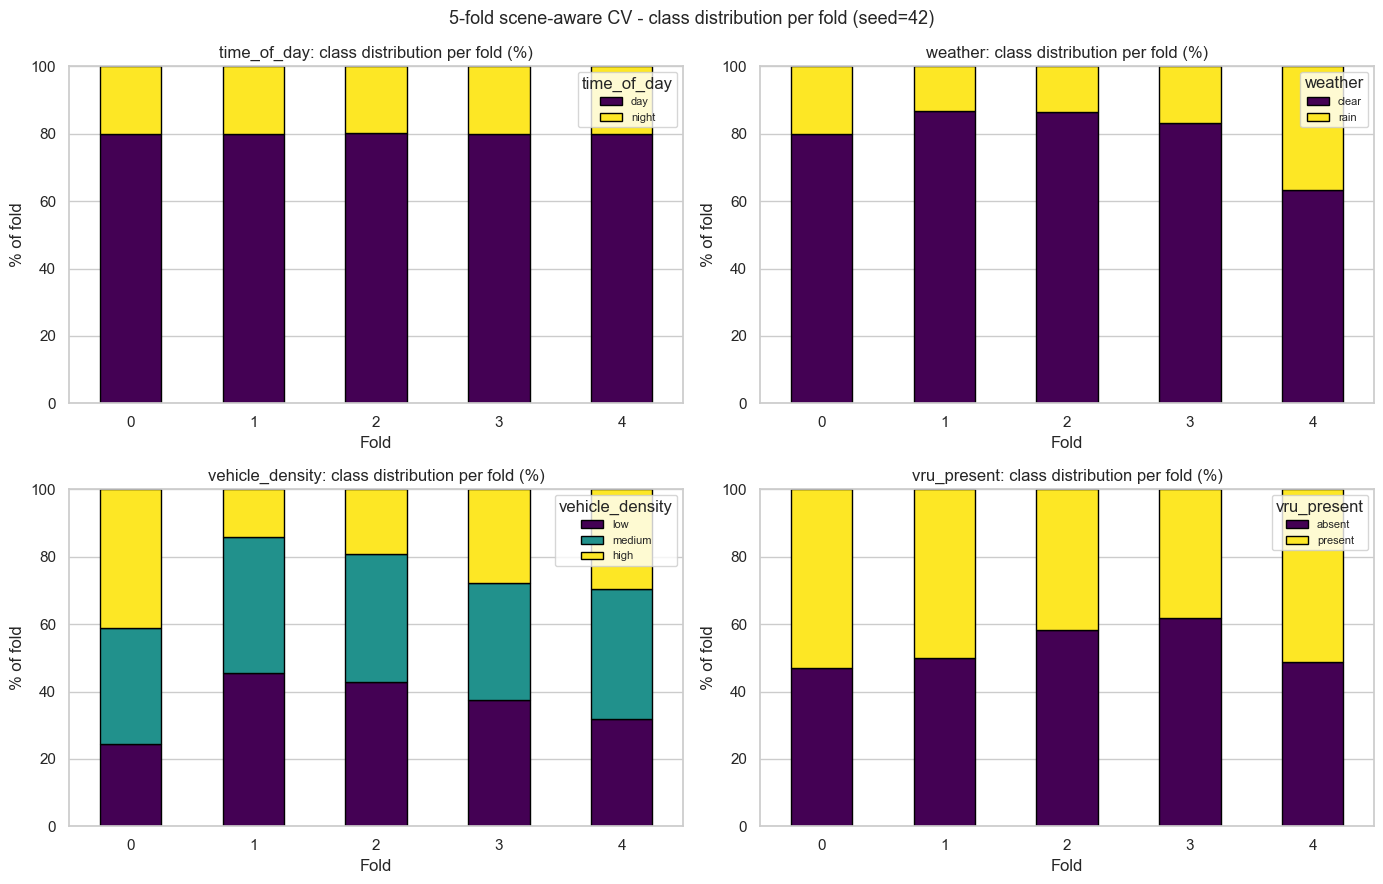

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, (attr, classes) in enumerate(attrs_info.items()):
    ax = axes[i // 2, i % 2]
    pivot = pd.crosstab(df_labels['fold'], df_labels[attr], normalize='index').reindex(
        columns=classes, fill_value=0) * 100
    pivot.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', edgecolor='black')
    ax.set_title(f'{attr}: class distribution per fold (%)')
    ax.set_xlabel('Fold')
    ax.set_ylabel('% of fold')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(title=attr, loc='upper right', fontsize=8)
    ax.set_ylim(0, 100)

plt.suptitle(f'{N_FOLDS}-fold scene-aware CV - class distribution per fold (seed={SPLIT_SEED})',
             fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fold_distributions.png', bbox_inches='tight')
plt.show()

## 9. Save Fold Metadata

In [14]:
kfold_metadata = {
    'dataset_version': DATASET_VERSION,
    'split_method':    f'{N_FOLDS}-fold scene-aware CV',
    'n_folds':         N_FOLDS,
    'split_seed':      SPLIT_SEED,
    'stratified_on':   STRATIFY_ON,
    'inner_cv':        '3-fold StratifiedKFold for tuning (applied in nb 04)',

    'scenes_per_fold': {
        int(k): int((df_scenes['fold'] == k).sum()) for k in range(N_FOLDS)
    },
    'keyframes_per_fold': {
        int(k): int((df_labels['fold'] == k).sum()) for k in range(N_FOLDS)
    },
    'leakage_check': {
        'scenes_in_multiple_folds': int(len(leaked_scenes)),
        'passed': bool(len(leaked_scenes) == 0),
    },
    'single_class_folds': single_class_flags,
    'class_distributions_per_fold': {},
}

for attr, classes in attrs_info.items():
    kfold_metadata['class_distributions_per_fold'][attr] = {}
    for k in range(N_FOLDS):
        fold_df = df_labels[df_labels['fold'] == k]
        kfold_metadata['class_distributions_per_fold'][attr][int(k)] = {
            cls: int((fold_df[attr] == cls).sum()) for cls in classes
        }

with open(SPLITS_DIR / 'kfold_metadata.json', 'w') as f:
    json.dump(kfold_metadata, f, indent=2)
print(f'Saved → {SPLITS_DIR / "kfold_metadata.json"}')
print()
print(json.dumps(kfold_metadata, indent=2))

Saved → data\processed\v1.0-trainval\splits\kfold_metadata.json

{
  "dataset_version": "v1.0-trainval",
  "split_method": "5-fold scene-aware CV",
  "n_folds": 5,
  "split_seed": 42,
  "stratified_on": "time_of_day",
  "inner_cv": "3-fold StratifiedKFold for tuning (applied in nb 04)",
  "scenes_per_fold": {
    "0": 30,
    "1": 30,
    "2": 30,
    "3": 30,
    "4": 30
  },
  "keyframes_per_fold": {
    "0": 1203,
    "1": 1199,
    "2": 1206,
    "3": 1209,
    "4": 1204
  },
  "leakage_check": {
    "scenes_in_multiple_folds": 0,
    "passed": true
  },
  "single_class_folds": [],
  "class_distributions_per_fold": {
    "time_of_day": {
      "0": {
        "day": 962,
        "night": 241
      },
      "1": {
        "day": 957,
        "night": 242
      },
      "2": {
        "day": 966,
        "night": 240
      },
      "3": {
        "day": 967,
        "night": 242
      },
      "4": {
        "day": 963,
        "night": 241
      }
    },
    "weather": {
      "0": {

## 10. Summary

In [15]:
print('=' * 70)
print('5-FOLD CV SPLIT GENERATION COMPLETE')
print('=' * 70)
print()
print(f'Method: {N_FOLDS}-fold scene-aware CV (stratified on {STRATIFY_ON})')
print(f'Seed:   {SPLIT_SEED}')
print()
print('Scenes per fold:')
for k in range(N_FOLDS):
    print(f'  Fold {k}: {int((df_scenes["fold"] == k).sum()):3d} scenes')
print()
print('Keyframes per fold:')
for k in range(N_FOLDS):
    print(f'  Fold {k}: {int((df_labels["fold"] == k).sum()):5d} keyframes')
print()
print('Zero scene leakage verified')
print(f'Single-class folds flagged: {len(single_class_flags)}')
print()
print('Next notebook: 04_classical_models.ipynb (REBUILD for 5-fold)')
print(f'  - 5 models x 4 attrs x 2 versions x 3 seeds x {N_FOLDS} folds = '
      f'{5*4*2*3*N_FOLDS} fits')
print('  - Inner 3-fold CV for hyperparameter tuning on each outer training set')
print('  - LabelEncoder baked in for XGBoost + MLP')
print('  - Skip-and-document any single-class folds flagged above')
print('  - Runtime: ~6-12h (SVM bottleneck on 6021 keyframes) - run overnight')

5-FOLD CV SPLIT GENERATION COMPLETE

Method: 5-fold scene-aware CV (stratified on time_of_day)
Seed:   42

Scenes per fold:
  Fold 0:  30 scenes
  Fold 1:  30 scenes
  Fold 2:  30 scenes
  Fold 3:  30 scenes
  Fold 4:  30 scenes

Keyframes per fold:
  Fold 0:  1203 keyframes
  Fold 1:  1199 keyframes
  Fold 2:  1206 keyframes
  Fold 3:  1209 keyframes
  Fold 4:  1204 keyframes

Zero scene leakage verified
Single-class folds flagged: 0

Next notebook: 04_classical_models.ipynb (REBUILD for 5-fold)
  - 5 models x 4 attrs x 2 versions x 3 seeds x 5 folds = 600 fits
  - Inner 3-fold CV for hyperparameter tuning on each outer training set
  - LabelEncoder baked in for XGBoost + MLP
  - Skip-and-document any single-class folds flagged above
  - Runtime: ~6-12h (SVM bottleneck on 6021 keyframes) - run overnight


---
## Reproducibility note

These 5-fold scene-aware splits are **fully reproducible**: with `SPLIT_SEED = 42` and the same `selected_scenes.csv`, `StratifiedKFold(shuffle=True, random_state=42)` produces identical fold assignments. The per-scene fold ids are also persisted in `scene_fold_assignments.csv` as a permanent record independent of the splitting logic.